1. Install Library

In [1]:
!pip install opencv-python

2. Import Library

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

3. Upload Dataset

In [3]:
from google.colab import files
uploaded = files.upload()

Saving banan5matang_jpg.rf.4e630edd3389a46fb923bf8e499b978c.jpg to banan5matang_jpg.rf.4e630edd3389a46fb923bf8e499b978c.jpg
Saving banana1matang_jpg.rf.34d322c6ed5d7f1ace7b99ad4039ce67.jpg to banana1matang_jpg.rf.34d322c6ed5d7f1ace7b99ad4039ce67.jpg
Saving banana2mentah_jpg.rf.3d7bb036e2db828c631640e81ff8d2ec.jpg to banana2mentah_jpg.rf.3d7bb036e2db828c631640e81ff8d2ec.jpg
Saving banana3mentah_jpg.rf.002df66d92ffd708664f41a027f56e77.jpg to banana3mentah_jpg.rf.002df66d92ffd708664f41a027f56e77.jpg
Saving banana4matang_jpg.rf.8325fb5260f65c0d1539361950dfdddb.jpg to banana4matang_jpg.rf.8325fb5260f65c0d1539361950dfdddb.jpg
Saving banana6matang_jpg.rf.41235cebf8962c6dc58d3f8b4482f96e.jpg to banana6matang_jpg.rf.41235cebf8962c6dc58d3f8b4482f96e.jpg
Saving banana7matang_jpg.rf.8fe838ebca304fc91151f627f32f5eb1.jpg to banana7matang_jpg.rf.8fe838ebca304fc91151f627f32f5eb1.jpg
Saving banana8mentah_jpg.rf.22dd41a84e42abc0ce5865b6c1c041f4.jpg to banana8mentah_jpg.rf.22dd41a84e42abc0ce5865b6c1c041f

4. Cek Dataset

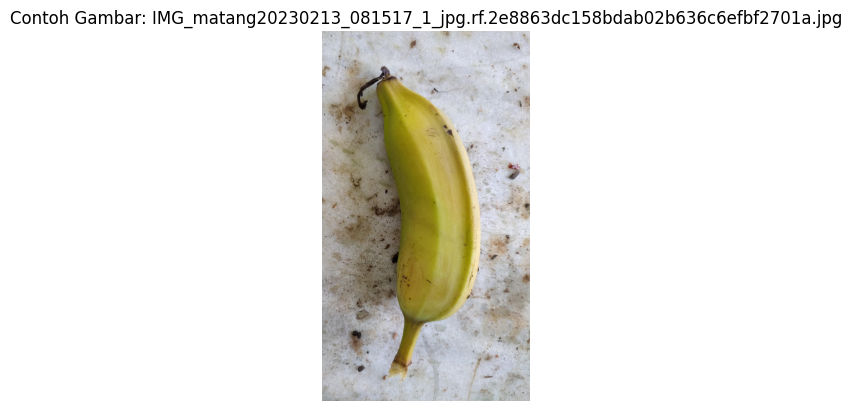

In [4]:
import random
import os

# Define dataset_path to point to the correct location where images were uploaded
dataset_path = '/content/'

# Check if the dataset path exists
if not os.path.exists(dataset_path):
    print(f"Error: Path tidak ditemukan: {dataset_path}")
else:
    # Get all image files directly from the dataset_path
    files = [f for f in os.listdir(dataset_path)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if len(files) == 0:
        print("Tidak ada gambar di direktori dataset.")
    else:
        # Select a random image to display
        file = random.choice(files)
        img_path = os.path.join(dataset_path, file)

        img = cv2.imread(img_path)

        if img is None:
            print(f"Gagal membaca gambar: {img_path}")
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.imshow(img)
            plt.title(f"Contoh Gambar: {file}") # Changed title since there are no class folders
            plt.axis('off')
            plt.show()

5. Fungsi Ekstraksi Fitur

In [5]:
def extract_features(image_path):
    if not os.path.exists(image_path):
        print(f"File tidak ditemukan: {image_path}")
        return None # Return None if file not found

    img = cv2.imread(image_path)
    if img is None:
        print(f"Gagal membaca gambar: {image_path}")
        return None # Return None if image cannot be read

    img = cv2.resize(img, (100, 100))

    # RGB
    r = np.mean(img[:,:,2])
    g = np.mean(img[:,:,1])
    b = np.mean(img[:,:,0])

    # HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h = np.mean(hsv[:,:,0])
    s = np.mean(hsv[:,:,1])
    v = np.mean(hsv[:,:,2])

    return [r, g, b, h, s, v]

6. Load Dataset + Ekstraksi

In [17]:
import re

data = []
labels = []

for file_name in os.listdir(dataset_path):
    file_path = os.path.join(dataset_path, file_name)

    if os.path.isfile(file_path) and file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
        try:
            features = extract_features(file_path)
            if features is not None:
                data.append(features)
                # Use the get_label_from_filename function to extract accurate labels
                label = get_label_from_filename(file_name)
                labels.append(label)
        except Exception as e:
            print(f"Error processing image {file_path}: {e}")

7. Data ke DataFrame

In [19]:
columns = ['R','G','B','H','S','V']
df = pd.DataFrame(data, columns=columns)
df['label'] = labels

df.head()

,R,G,B,H,S,V,label
0,162.0578,158.7537,150.3213,59.0452,35.9709,166.6011,busuk
1,139.2383,127.6603,93.6140,28.9194,93.4211,142.4733,matang
2,165.4025,162.1851,142.5174,51.5320,46.5129,168.3949,matang
3,175.6176,170.9454,156.9029,49.4780,39.4432,178.0088,matang
4,163.3675,159.2367,146.5393,58.8650,42.4518,167.2270,matang


8. Split Data

In [20]:
X = df[columns]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

9. Training Random Forest

In [21]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

10. Evaluasi Model

In [22]:
y_pred = model.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Akurasi: 0.9

Classification Report:
              precision    recall  f1-score   support

       busuk       0.83      1.00      0.91         5
      matang       0.88      1.00      0.93         7
      mentah       1.00      0.75      0.86         8

    accuracy                           0.90        20
   macro avg       0.90      0.92      0.90        20
weighted avg       0.91      0.90      0.90        20



11. Feature Importance

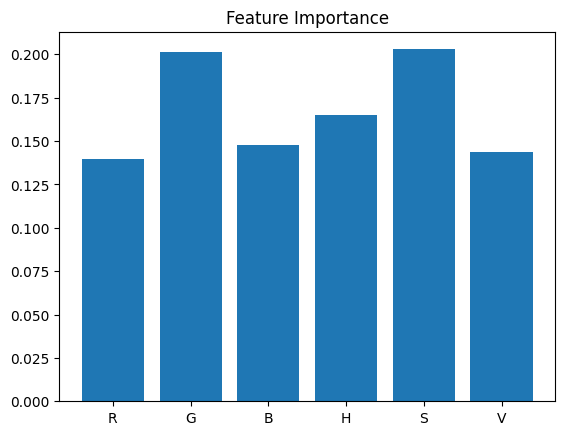

In [23]:
importance = model.feature_importances_

plt.bar(columns, importance)
plt.title("Feature Importance")
plt.show()

12. Prediksi Gambar Baru

In [26]:
def predict_uploaded_images(uploaded):
    print("===================================")
    print("      PREDIKSI GAMBAR BARU        ")
    print("===================================")

    for i, file_name in enumerate(uploaded.keys(), start=1):
        print(f"\nGambar ke-{i}: {file_name}")
        print("-----------------------------------")

        show_prediction(file_name)

In [27]:
predict_uploaded_images(uploaded)

Output hidden; open in https://colab.research.google.com to view.